<a href="https://colab.research.google.com/github/Rachani02/Statistical-Learning-e22282/blob/main/Assignment_7_Kalman_Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1. Analytical Derivative**

we assume standard linear Kalman filter conditions:

 *The process noise $w_{k-1}$ is zero-mean Gaussian with covariance $\Sigma_p$, i.e., $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$.

 *The measurement noise $z_k$ is zero-mean Gaussian with covariance $\Sigma_m$, i.e., $z_k \sim \mathscr{N}(0, \Sigma_m)$.

 *$x^{+}_{k-1}$, $w_{k-1}$, and $z_k$ are mutually independent.

1. Show that $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$

Since $x_k^-$ is a linear combination of independent Gaussian random variables ($x^{+}_{k-1}$ and $w_{k-1}$), it is also Gaussian distributed. We find its mean and covariance using the properties of expectation ($\mathbb{E}$) and variance ($\text{Var}$):Mean ($m_k^-$):

$$\begin{aligned}
m_k^- \triangleq \mathbb{E}[x_k^-] &= \mathbb{E}[A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}] \\
&= A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}] \\
&= A_{k-1}m_{k-1} + G_{k-1}(0) \\
&= A_{k-1}m_{k-1}
\end{aligned}$$

Covariance ($P_k^-$):Since $x^{+}_{k-1}$ and $w_{k-1}$ are independent, their covariance is zero. Thus:

$$\begin{aligned}
P_k^- \triangleq \text{Var}(x_k^-) &= \text{Var}(A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}) \\
&= A_{k-1}\text{Var}(x^{+}_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T \\
&= A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T
\end{aligned}$$

Hence, $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$.

2. Show that $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$

Since $y_k^- = H_k x_k^- + z_k$ is a linear combination of Gaussian random variables, it is also Gaussian.Mean:

$$\begin{aligned}
\mathbb{E}[y_k^-] &= \mathbb{E}[H_k x_k^- + z_k] = H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] \\
&= H_k m_k^- + 0 = H_k m_k^-
\end{aligned}$$

Covariance:Since $x_k^-$ depends on past noise terms and $z_k$ is independent of the past, $x_k^-$ and $z_k$ are uncorrelated:

$$\begin{aligned}
\text{Var}(y_k^-) &= \text{Var}(H_k x_k^- + z_k) = H_k \text{Var}(x_k^-)H_k^T + \text{Var}(z_k) \\
&= H_k P_k^- H_k^T + \Sigma_m
\end{aligned}$$

Hence, $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$.

3. Show the Joint Distribution of $\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix}$

Because both are linear transformations of the underlying independent Gaussian variables, they are jointly Gaussian distributed:

$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left( \mu_{\text{joint}}, \Sigma_{\text{joint}} \right)$$

Joint Mean ($\mu_{\text{joint}}$):

$$\mu_{\text{joint}} = \begin{bmatrix} \mathbb{E}[x_k^-] \\ \mathbb{E}[y^{-}_k] \end{bmatrix} = \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}$$

Joint Covariance ($\Sigma_{\text{joint}}$):The joint covariance matrix has the block structure:$$\Sigma_{\text{joint}} = \begin{bmatrix} \text{Var}(x_k^-) & \text{Cov}(x_k^-, y_k^-) \\ \text{Cov}(y_k^-, x_k^-) & \text{Var}(y_k^-) \end{bmatrix}$$

We already know $\text{Var}(x_k^-) = P_k^-$ and $\text{Var}(y_k^-) = H_k P_k^- H_k^T + \Sigma_m$. We just need the cross-covariance term:

$$\begin{aligned}
\text{Cov}(x_k^-, y_k^-) &= \mathbb{E}\left[ (x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T \right] \\
&= \mathbb{E}\left[ (x_k^- - m_k^-)(H_k x_k^- + z_k - H_k m_k^-)^T \right] \\
&= \mathbb{E}\left[ (x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T \right] \\
&= \mathbb{E}\left[ (x_k^- - m_k^-)(x_k^- - m_k^-)^T H_k^T \right] + \mathbb{E}\left[ (x_k^- - m_k^-)z_k^T \right]
\end{aligned}$$

Since $x_k^-$ and $z_k$ are independent, $\mathbb{E}\left[ (x_k^- - m_k^-)z_k^T \right] = 0$.

Thus:

$$\text{Cov}(x_k^-, y_k^-) = \text{Var}(x_k^-)H_k^T = P_k^- H_k^T$$

Naturally, $\text{Cov}(y_k^-, x_k^-) = \left(\text{Cov}(x_k^-, y_k^-)\right)^T = H_k P_k^-$.Plugging these back into the block matrix yields:

$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right). \quad\$$

4. Show that $x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k)$

This relies on the standard theorem for the conditional distribution of a joint Multivariate Gaussian.If a joint distribution is given by:

$$\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix} \right)$$

Then the conditional distribution $(X \mid Y = y)$ is Gaussian with:

$$\mathbb{E}[X \mid Y = y] = \mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(y - \mu_Y)$$$$\text{Var}(X \mid Y = y) = \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}$$

Mapping our results from Part 3 into this theorem:

$X = x_k^- \implies \mu_X = m_k^-, \quad \Sigma_{XX} = P_k^-$$Y = y_k^- \implies \mu_Y = H_k m_k^-, \quad \Sigma_{YY} = H_k P_k^- H_k^T + \Sigma_m$$\Sigma_{XY} = P_k^- H_k^T$ and $\Sigma_{YX} = H_k P_k^-$

Applying the formulas:Kalman Gain ($K_k$):$$K_k \triangleq \Sigma_{XY}\Sigma_{YY}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

Updated Mean ($m_k$):$$m_k = \mu_X + K_k(y^{\mathrm{obs}}_{k} - \mu_Y) = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

Updated Covariance ($P_k$):$$\begin{aligned}
P_k &= \Sigma_{XX} - K_k \Sigma_{YX} \\
&= P_k^- - K_k (H_k P_k^-) \\
&= (I - K_k H_k) P_k^-
\end{aligned}$$

Hence, $x^{+}_k \sim \mathscr{N}(m_k, P_k)$ with the specified updates.

5. Find $\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$ and $\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$

By definition, the conditional notation $x^{+}_k \triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$ means that the parameters derived directly in Part 4 are the exact answers to this question.Conditional Expected Value:$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

Conditional Variance:$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k = (I - K_k H_k) P_k^-$$

---

**Question 1-D Example**

1. Derivation of $m_k^-$ and $P_k^-$

Given $x^+_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, q)$ are independent:

Mean ($m_k^-$):

$$m_k^- = \mathbb{E}[x^-_k] = \mathbb{E}[a\,x^+_{k-1} + w_{k-1}] = a\,\mathbb{E}[x^+_{k-1}] + \mathbb{E}[w_{k-1}] = a\,m_{k-1} + 0 = a\,m_{k-1}$$

Variance ($P_k^-$):

Since $x^+_{k-1}$ and $w_{k-1}$ are independent, their covariance is zero:

$$P_k^- = \text{Var}(x^-_k) = \text{Var}(a\,x^+_{k-1} + w_{k-1}) = a^2\text{Var}(x^+_{k-1}) + \text{Var}(w_{k-1}) = a^2 P_{k-1} + q$$

2. Derivation of updated Mean $m_k$ and Variance $P_k$

From the standard multivariate Gaussian conditioning theorem applied to the joint state-measurement distribution, we define the innovation covariance $S_k$ and Kalman gain $K_k$:

$$S_k = \text{Var}(y_k^-) = h^2 P_k^- + r$$

$$K_k = \frac{\text{Cov}(x_k^-, y_k^-)}{\text{Var}(y_k^-)} = \frac{P_k^- h}{S_k} = \frac{P_k^- h}{h^2 P_k^- + r}$$

Posterior Mean ($m_k$):

$$m_k = m_k^- + K_k v_k = m_k^- + K_k(y^{\mathrm{obs}}_k - h\,m_k^-) = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$

Posterior Variance ($P_k$):

$$P_k = (1 - K_k h)P_k^- = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$

3. Predictive Measurement Distribution: $p(y^-_k \mid Y_{k-1})$

Before incorporating $y_k^{\mathrm{obs}}$, the sensor model is $y_k^- = h\,x_k^- + z_k$, given $x_k^- \mid Y_{k-1} \sim \mathscr{N}(m_k^-, P_k^-)$ and $z_k \sim \mathscr{N}(0, r)$.

Mean:

$$\mathbb{E}[y_k^- \mid Y_{k-1}] = \mathbb{E}[h\,x_k^- + z_k \mid Y_{k-1}] = h\,\mathbb{E}[x_k^- \mid Y_{k-1}] + \mathbb{E}[z_k] = h\,m_k^-$$

Variance:

Since $x_k^-$ and $z_k$ are independent:

$$\text{Var}(y_k^- \mid Y_{k-1}] = \text{Var}(h\,x_k^- + z_k \mid Y_{k-1}) = h^2\text{Var}(x_k^- \mid Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$$

Thus, $p(y^-_k \mid Y_{k-1}) = \mathscr{N}(h\,m_k^-,\; h^2 P_k^- + r)$.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm
from IPython.display import HTML

# =====================================================================
# 1. System Parameters & Configuration
# =====================================================================
a = 1.0       # State transition coefficient
h = 2.0       # Measurement coefficient
q = 0.5       # Process noise variance
r = 1.0       # Measurement noise variance

# True trajectory generation setup
np.random.seed(42)
num_steps = 15
x_true = np.zeros(num_steps)
y_obs = np.zeros(num_steps)

# Generate synthetic trajectory data
x_true[0] = 0.0
for k in range(1, num_steps):
    x_true[k] = a * x_true[k-1] + np.random.normal(0, np.sqrt(q))
    y_obs[k] = h * x_true[k] + np.random.normal(0, np.sqrt(r))

# =====================================================================
# 2. Kalman Filtering Loop (Save histories)
# =====================================================================
m_prior_hist, P_prior_hist = [], []
m_post_hist, P_post_hist = [], []

# Prior initialization at step 0
m = 0.0
P = 2.0

for k in range(num_steps):
    # Time Update (Prior step)
    if k > 0:
        m_minus = a * m
        P_minus = a**2 * P + q
    else:
        m_minus = m
        P_minus = P

    # Measurement Update (Posterior step)
    if k > 0:
        S = h**2 * P_minus + r
        K = (P_minus * h) / S
        m = m_minus + K * (y_obs[k] - h * m_minus)
        P = (1 - K * h) * P_minus
    else:
        m = m_minus
        P = P_minus

    m_prior_hist.append(m_minus)
    P_prior_hist.append(P_minus)
    m_post_hist.append(m)
    P_post_hist.append(P)

# =====================================================================
# 3. Setup Animation & Rendering Backend
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x_axis = np.linspace(-6, 6, 500)
y_axis = np.linspace(-12, 12, 500)

def update(k):
    if k == 0:
        return ax1, ax2 # Skip frame index 0 (initial conditions)

    ax1.clear()
    ax2.clear()

    # -----------------------------------------
    # Left Plot: State Distributions (x)
    # -----------------------------------------
    prior_pdf = norm.pdf(x_axis, m_prior_hist[k], np.sqrt(P_prior_hist[k]))
    post_pdf = norm.pdf(x_axis, m_post_hist[k], np.sqrt(P_post_hist[k]))

    ax1.plot(x_axis, prior_pdf, 'r--', label=f'Prior $p(x^-_k)$', linewidth=2)
    ax1.fill_between(x_axis, prior_pdf, color='red', alpha=0.15)
    ax1.plot(x_axis, post_pdf, 'g-', label=f'Posterior $p(x^+_k)$', linewidth=2)
    ax1.fill_between(x_axis, post_pdf, color='green', alpha=0.2)
    ax1.axvline(x_true[k], color='black', linestyle=':', linewidth=2, label='True State ($x_k$)')

    ax1.set_title(f"State Estimation Space (Step k={k})")
    ax1.set_xlabel("State space (x)")
    ax1.set_ylabel("Probability Density")
    ax1.set_xlim([-6, 6])
    ax1.set_ylim([0, 1.2])
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # -----------------------------------------
    # Right Plot: Measurement Distributions (y)
    # -----------------------------------------
    pred_y_mean = h * m_prior_hist[k]
    pred_y_var = h**2 * P_prior_hist[k] + r
    post_y_mean = h * m_post_hist[k]
    post_y_var = h**2 * P_post_hist[k] + r

    pred_y_pdf = norm.pdf(y_axis, pred_y_mean, np.sqrt(pred_y_var))
    post_y_pdf = norm.pdf(y_axis, post_y_mean, np.sqrt(post_y_var))

    ax2.plot(y_axis, pred_y_pdf, 'm--', label='Predictive $p(y^-_k|Y_{k-1})$', linewidth=2)
    ax2.fill_between(y_axis, pred_y_pdf, color='magenta', alpha=0.1)
    ax2.plot(y_axis, post_y_pdf, 'b-', label='Post-Predictive $p(y^-_k|Y_k)$', linewidth=2)
    ax2.fill_between(y_axis, post_y_pdf, color='blue', alpha=0.15)
    ax2.axvline(y_obs[k], color='darkorange', linestyle='-', linewidth=2, label='Observed Sensor ($y^{obs}_k$)')

    ax2.set_title(f"Measurement Space Distribution (Step k={k})")
    ax2.set_xlabel("Measurement value (y)")
    ax2.set_ylabel("Probability Density")
    ax2.set_xlim([-12, 12])
    ax2.set_ylim([0, 0.6])
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

# Assemble the animation engine
ani = animation.FuncAnimation(fig, update, frames=range(1, num_steps), interval=1200, repeat=True)

# Close static window to avoid empty duplicates
plt.close()

# Render interactive HTML5 player directly inside notebook output
HTML(ani.to_jshtml())

/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

---

**Q 2D-Position Estimation**

**part A**

1. Derivation of the State Transition Matrix $A$A constant-velocity system implies that the acceleration is zero on average, and any change in velocity is captured by the noise term. Over a small time interval $\Delta t$, the kinematics of the system for both the $x$ and $y$ coordinates follow standard linear motion physics:

Positions:

$$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$$$$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$$Velocities (assuming constant velocity modulo noise):$$v_x(k) = v_x(k-1)$$$$v_y(k) = v_y(k-1)$$

We write this system of 4 linear equations in vector-matrix form $x_k^- = A x_{k-1}^+$:$$\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 \cdot p_x(k-1) + 0 \cdot p_y(k-1) + \Delta t \cdot v_x(k-1) + 0 \cdot v_y(k-1) \\
0 \cdot p_x(k-1) + 1 \cdot p_y(k-1) + 0 \cdot v_x(k-1) + \Delta t \cdot v_y(k-1) \\
0 \cdot p_x(k-1) + 0 \cdot p_y(k-1) + 1 \cdot v_x(k-1) + 0 \cdot v_y(k-1) \\
0 \cdot p_x(k-1) + 0 \cdot p_y(k-1) + 0 \cdot v_x(k-1) + 1 \cdot v_y(k-1)
\end{bmatrix}$$

Factoring out the components of $x_{k-1}^+$, we obtain the state transition matrix $A$:$$A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}.$$

2. Derivation of the Process Noise Mapping Matrix $G$The process noise vector $w_{k-1}$ typically represents a random acceleration vector acting on the system during the interval $\Delta t$:

$$w_{k-1} = \begin{bmatrix} a_x(k-1) \\ a_y(k-1) \end{bmatrix}.$$

According to Newtonian physics under a constant acceleration $a$ over a time step $\Delta t$, the updates to position and velocity are given by:

$\Delta \text{position} = \frac{1}{2}a\Delta t^2$$\Delta \text{velocity} = a\Delta t$

Applying this independently to the $x$ and $y$ coordinates gives:

$$\begin{aligned}
p_x(k) &= p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}\Delta t^2 a_x(k-1) \\
p_y(k) &= p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}\Delta t^2 a_y(k-1) \\
v_x(k) &= v_x(k-1) + \Delta t a_x(k-1) \\
v_y(k) &= v_y(k-1) + \Delta t a_y(k-1)
\end{aligned}$$

Isolating the perturbation terms that depend on $w_{k-1}$, the noise mapping equation $G w_{k-1}$ expands to:

$$G w_{k-1} =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 a_x(k-1) + 0 \cdot a_y(k-1) \\
0 \cdot a_x(k-1) + \frac{1}{2}\Delta t^2 a_y(k-1) \\
\Delta t a_x(k-1) + 0 \cdot a_y(k-1) \\
0 \cdot a_x(k-1) + \Delta t a_y(k-1)
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x(k-1)\\
a_y(k-1)
\end{bmatrix}.$$

Thus, the process noise transformation matrix is verified as:

$$G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.$$

3. Derivation of the Measurement Matrix $H$The measurement vector $y_k^-$ maps how the full internal state relates directly to what our sensors track. We are given that the sensor measures only the position components, ignoring the velocity components:

$$y_k^- = \begin{bmatrix} p_x^{\mathrm{meas}}(k) \\ p_y^{\mathrm{meas}}(k) \end{bmatrix} = \begin{bmatrix} p_x(k) \\ p_y(k) \end{bmatrix} + z_k.$$

Expressing the extracted position coordinates as a linear combination of all 4 state dimensions in $x_k$:

$$\begin{bmatrix} p_x(k) \\ p_y(k) \end{bmatrix} =
\begin{bmatrix}
1 \cdot p_x(k) + 0 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k) \\
0 \cdot p_x(k) + 1 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k)
\end{bmatrix}.$$

Extracting the coefficients into the matrix form $H x_k$ yields:$$H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}.$$

**part B**

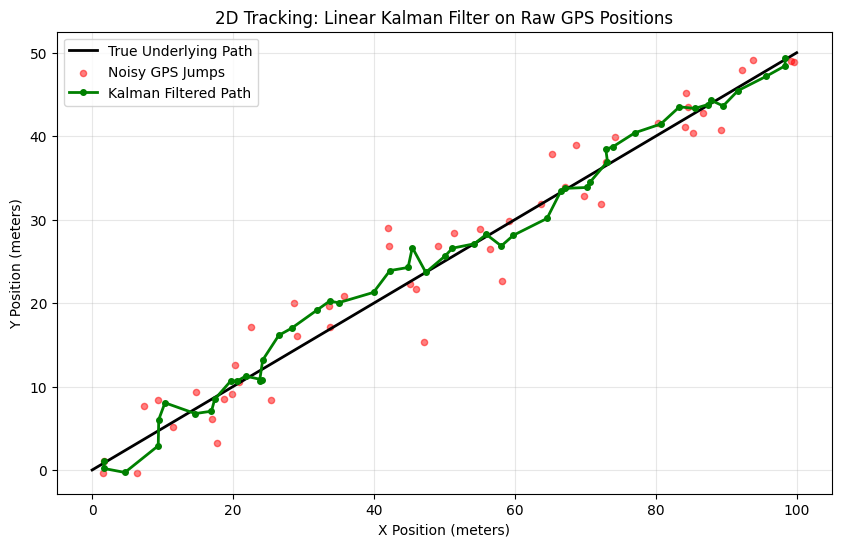

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def kalman_filter_2d_gps(positions_measured, dt=1.0, q_var=0.05, r_var=5.0):
    """
    Filters a sequence of noisy 2D GPS coordinates using a Constant Velocity Kalman Filter.

    Parameters:
    -----------
    positions_measured : numpy.ndarray
        An Nx2 array of noisy measurements: [[p_x1, p_y1], [p_x2, p_y2], ...]
    dt : float
        Time step between measurements in seconds.
    q_var : float
        Process noise variance (how much the target accelerates randomly).
    r_var : float
        Measurement noise variance (how noisy the GPS sensor is).

    Returns:
    --------
    states_estimated : numpy.ndarray
        An Nx4 array of filtered states: [[p_x, p_y, v_x, v_y], ...]
    covariances_estimated : numpy.ndarray
        An Nx4x4 array of state covariance matrices over time.
    """
    num_steps = len(positions_measured)

    # --- 1. Define Model Matrices ---
    # State transition matrix
    A = np.array([
        [1, 0, dt,  0],
        [0, 1,  0, dt],
        [0, 0,  1,  0],
        [0, 0,  0,  1]
    ])

    # Process noise transformation matrix
    G = np.array([
        [0.5 * dt**2,           0],
        [          0, 0.5 * dt**2],
        [         dt,           0],
        [          0,          dt]
    ])

    # Measurement matrix (only observes position components)
    H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ])

    # Covariance matrices
    Sigma_p = np.eye(2) * q_var          # 2x2 process noise covariance
    Q = G @ Sigma_p @ G.T                # 4x4 mapped process noise covariance
    R = np.eye(2) * r_var                # 2x2 measurement noise covariance

    # --- 2. Initialize Filter States ---
    # Start state estimate using the first GPS reading; initial velocities assumed 0
    m = np.array([positions_measured[0, 0], positions_measured[0, 1], 0.0, 0.0])

    # Initial certainty matrix (high uncertainty for velocities)
    P = np.diag([r_var, r_var, 10.0, 10.0])

    # Storage arrays for results
    states_estimated = np.zeros((num_steps, 4))
    covariances_estimated = np.zeros((num_steps, 4, 4))

    states_estimated[0] = m
    covariances_estimated[0] = P

    # --- 3. Kalman Filtering Loop ---
    for k in range(1, num_steps):
        # --- PREDICT (Time Update) ---
        m_minus = A @ m
        P_minus = A @ P @ A.T + Q

        # --- UPDATE (Measurement Correction) ---
        y_obs = positions_measured[k]       # Current GPS observation

        # Innovation covariance
        S = H @ P_minus @ H.T + R

        # Optimal Kalman Gain
        K = P_minus @ H.T @ np.linalg.inv(S)

        # Update mean and covariance
        m = m_minus + K @ (y_obs - H @ m_minus)
        P = (np.eye(4) - K @ H) @ P_minus

        # Save steps
        states_estimated[k] = m
        covariances_estimated[k] = P

    return states_estimated, covariances_estimated


# =====================================================================
# 4. Simulation & Validation Example
# =====================================================================
if __name__ == "__main__":
    np.random.seed(42)
    steps = 50
    delta_t = 1.0

    # Generate an ideal smooth ground truth trajectory (constant velocity)
    true_px = np.linspace(0, 100, steps)
    true_py = np.linspace(0, 50, steps)

    # Inject heavy random Gaussian noise to simulate cheap GPS tracking
    gps_noise_std = 3.5  # Standard deviation of GPS error
    measured_px = true_px + np.random.normal(0, gps_noise_std, steps)
    measured_py = true_py + np.random.normal(0, gps_noise_std, steps)

    gps_measurements = np.column_stack((measured_px, measured_py))

    # Run the filter method
    # We pass r_var = gps_noise_std**2 because we know our sensor noise profile
    filtered_states, _ = kalman_filter_2d_gps(
        gps_measurements,
        dt=delta_t,
        q_var=0.1,
        r_var=gps_noise_std**2
    )

    # --- 5. Plot the tracking performance ---
    plt.figure(figsize=(10, 6))
    plt.plot(true_px, true_py, 'k-', label='True Underlying Path', linewidth=2)
    plt.scatter(gps_measurements[:, 0], gps_measurements[:, 1], color='red', alpha=0.5, s=20, label='Noisy GPS Jumps')
    plt.plot(filtered_states[:, 0], filtered_states[:, 1], 'g-o', label='Kalman Filtered Path', linewidth=2, markersize=4)

    plt.title("2D Tracking: Linear Kalman Filter on Raw GPS Positions")
    plt.xlabel("X Position (meters)")
    plt.ylabel("Y Position (meters)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()